# ITIES Detect — Colab MVP

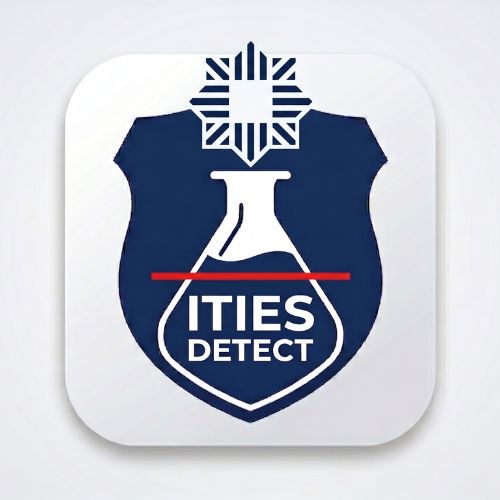

## Założenia

Punkty są brane zgodnie z notatką profesora:

- `1` = pik ujemny `TPrA+`, minimum na **reverse sweep**,
- `2` = pik dodatni `TPrA+`, maksimum na **forward sweep**,
- `3` = pik ujemny analitu/amfetaminy, minimum na **reverse sweep**,
- `4` = pik dodatni analitu/amfetaminy, maksimum na **forward sweep**.

```text
nieparzyste 1 i 3 = sygnały ujemne / reverse sweep
parzyste 2 i 4 = sygnały dodatnie / forward sweep
```

Wzory:

```text
E5 = (E1 + E2) / 2
E6 = (E3 + E4) / 2
ΔE_s = E6 − E5
```

Notebook wybiera dominujące pary pików na właściwych gałęziach CV i ocenia zgodność z profilem amfetaminy (`ΔE_s ≈ 0.350 V`).

## Kalibracja osi potencjału

Surowa oś `E` dryfuje między pomiarami (elektrody, ustawienia potencjostatu) — wartości bezwzględne są nieporównywalne. Notebook przesuwa całą oś tak, by środek pary `TPrA+` (`E5`) trafił na termodynamiczną stałą `−0.091 V` — galwaniczny potencjał przejścia jonu `TPrA+` z fazy wodnej do organicznej.

```text
offset = −0.091 − E5_surowe
E_po_kalibracji = E_surowe + offset
```

Oś wykresu **„E [V] po kalibracji"** jest zakotwiczona do wzorca TPrA — dopiero na niej `ΔE_s` jest porównywalny między pomiarami. Wartość **`offset`** (typowo ok. −0.42 V) profesor znajdzie na **podpisie osi X każdego wykresu**; offset mocno odstający (np. −0.8 V) wskazuje na błędną selekcję piku TPrA.


In [ ]:
# Uruchom środowisko

import io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
from scipy.signal import find_peaks, peak_widths, savgol_filter
from IPython.display import display

try:
    from google.colab import files
except Exception:
    files = None

# ─── Stałe analityczne (NIE zmieniać bez retestowania na 37 plikach) ─────────
TPRA_TARGET_V              = -0.091
AMPHETAMINE_TARGET_DELTA_V = 0.350
DETECTION_TOLERANCE_V      = 0.010
UNCERTAIN_TOLERANCE_V      = 0.015

# ─── Detekcja pików ───────────────────────────────────────────────────────────
PEAK_PROMINENCE_A       = 1.5e-7        # stały próg szumu aparaturowego (0.15 µA)
PEAK_DISTANCE_POINTS    = 20
MAX_PEAK_WIDTH_FRACTION = 0.35

# ─── Okna selekcji TPrA w surowych potencjałach (empiryczne, 37 plików) ──────
WIN_TPRA_POS_RAW      = (0.20, 0.45)   # TPrA+ na forward
WIN_TPRA_NEG_RAW      = (0.05, 0.35)   # TPrA− na backward
SHIFT_MIN             = -0.65           # sanity check shift
SHIFT_MAX             = -0.20
ANALYTE_MIN_OFFSET    = 0.10            # analit min 100 mV na prawo od TPrA
CYCLE_PROMINENCE_FRAC = 0.30            # próg detekcji multi-cyklu

# ─── Baseline piku (przepis prof. z 20.07.2026, zbieżny z HURNY) ─────────────
BASELINE_SEG_MAX_V   = 0.150    # odcinek bazowy: maks. 150 mV (przepis: 100–150 mV)
BASELINE_SEG_MIN_V   = 0.030    # minimalna długość odcinka do fitu
BASELINE_BAND_FRAC   = 0.25     # "płaskość": ΔI odcinka ≤ 25% wzrostu na stoku (ΔI ≪ ΔI′)
BASELINE_MIN_PTS     = 8        # minimum punktów do fitu liniowego
BASELINE_FLAT_WIN_V  = 0.080   # szerokość okna "najpłaskszego odcinka" (bez piku odniesienia)
BASELINE_EDGE_SKIP_V = 0.020   # ile odciąć od krawędzi gałęzi (okno rozpuszczalnika)

# ─── Kształt piku i Ip dwiema procedurami (prof. Półtorak, konsultacja 18.08.2026) ──
# Pik WYRAŹNY: prosta przez maksimum ∥ osi prądowej, Ip = I(max) − baseline(E_max).
# Pik SŁABY (bez wyraźnego maksimum, m.in. przy zbyt dużym stężeniu): dwie styczne,
# Ip = I(przecięcie stycznych) − baseline(E_przecięcia). Rozbieżność metod 7–19 %.
# Próg ZMIERZONY 20.08.2026 na 28 plikach CC (lab czyta je wszystkie jako piki wyraźne):
# mediana spadku za maksimum to tylko 0,20 wzrostu, bo sygnał siedzi na rosnącym tle.
# Kryterium „spadek" nie rozdziela więc pików; przy 0,30 pogarszało kalibrację o 8 %.
# 0,05 = praktycznie brak zawrotu prądu (ramię/plateau) — tylko wtedy procedura B.
PEAK_SHAPE_DROP_FRAC   = 0.05    # spadek za maksimum < 5 % wzrostu ⇒ brak wyraźnego maksimum
PEAK_SHAPE_LOOK_V      = 0.080   # okno za maksimum, w którym szukamy spadku
TANGENT_FIT_PTS        = 7       # punktów na każdą styczną (stok, odcinek za pikiem)
# Kandydaci „ramię" (pik słaby, którego find_peaks nie widzi) z przecięcia stycznych.
# EKSPERYMENT: domyślnie WYŁĄCZONE — bez zbioru negatywów nie wolno mierzyć swoistości.
WEAK_PEAK_CANDIDATES   = False

# ─── Tryb wygładzania: "savgol" (zalecany), "raw" (weryfikacja), "ma" (regresja)
DETECTION_MODE = "savgol"

# ─── Kolory wykresu ────────────────────────────────────────────────────────────
FORWARD_COLOR = "#64748B"   # forward sweep — stalowy szary (spokojny, by kropki dominowały)
RETURN_COLOR  = "#7C9A86"   # reverse sweep — szarozielony
TPRA_COLOR    = "#2563EB"   # TPrA: punkty 1, 2 i linia E5 — niebieski
ANALYTE_COLOR = "#DC2626"   # analit: punkty 3, 4 i linia E6 — czerwony
POINT_COLORS  = {
    "1": TPRA_COLOR,    "2": TPRA_COLOR,      # TPrA−, TPrA+
    "3": ANALYTE_COLOR, "4": ANALYTE_COLOR,   # Analit−, Analit+
    "5": TPRA_COLOR,    "6": ANALYTE_COLOR,   # E5 (środek TPrA), E6 (środek analitu)
}

RESULTS    = {}
FILE_STORE = {}

# ─── Narzędzia ogólne ─────────────────────────────────────────────────────────

def to_num(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    return pd.to_numeric(
        series.astype(str)
        .str.replace("﻿", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )

def numeric_ratio(series):
    return float(to_num(series).notna().mean()) if len(series) else 0.0

def norm_col(name):
    return re.sub(r"[\s_\-./()]+", "", str(name).replace("﻿", "").lower())

# ─── Status → etykieta wykresu ────────────────────────────────────────────────

def outcome_info(result):
    status = result.get("status")
    if status == "detected":
        return "positive", "#16a34a", "✅"
    if status in ("uncertain",):
        return "inconclusive", "#ca8a04", "⚠️"
    if status in ("invalid", "too_few_points"):
        return "inconclusive", "#ca8a04", "⚠️"
    if status == "MEASUREMENT_QUALITY_FAIL":
        return "measurement_fail", "#475569", "🛑"
    return "negative", "#dc2626", "❌"

# ─── Nagłówek sekcji wyniku ───────────────────────────────────────────────────

def show_section_header(result):
    _, _, icon = outcome_info(result)
    status_label = result.get("status_pl", result.get("status", "?"))
    file_name    = result.get("file_name", "plik")
    print("\n" + "─" * 68)
    print(f"ITIES DETECT — {file_name}  |  {icon} {status_label}")
    print("─" * 68)

# ─── Tytuł wykresu ────────────────────────────────────────────────────────────

def set_colored_plot_title(ax, file_name, outcome, color):
    prefix = f"ITIES DETECT x {file_name} | "
    fig    = ax.figure
    ax.set_title("")
    fontsize = 15
    fp       = FontProperties(size=fontsize, weight="bold")
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    w_prefix, _, _ = renderer.get_text_width_height_descent(prefix, fp, ismath=False)
    w_status, _, _ = renderer.get_text_width_height_descent(outcome, fp, ismath=False)
    bbox            = ax.get_window_extent(renderer=renderer)
    x0              = (bbox.x0 + bbox.x1 - w_prefix - w_status) / 2
    y0              = bbox.y1 + 12
    x_prefix, y_title = fig.transFigure.inverted().transform((x0, y0))
    x_status, _       = fig.transFigure.inverted().transform((x0 + w_prefix, y0))
    fig.text(x_prefix, y_title, prefix, color="#111827", fontproperties=fp, ha="left", va="bottom")
    fig.text(x_status, y_title, outcome, color=color,    fontproperties=fp, ha="left", va="bottom")

def fmt_v(value):
    return "" if value is None else f"{float(value):+.3f} V"

def fmt_uA(value):
    return "" if value is None else f"{float(value) * 1e6:+.2f} µA"

def style_cv_axes(fig, ax):
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")
    ax.tick_params(colors="#374151", labelsize=11)
    ax.xaxis.label.set_color("#374151")
    ax.yaxis.label.set_color("#374151")
    for spine in ax.spines.values():
        spine.set_color("#d1d5db")
    ax.grid(color="#e5e7eb", alpha=0.9, linewidth=0.7)
    ax.axhline(0, color="#9ca3af", linewidth=0.6, alpha=0.6)

def plot_cv_branches(ax, E, I, shift=0.0, calibrated=True):
    try:
        upper, lower = split_cv(E)
        ax.plot(E[upper] + shift, I[upper] * 1e6, color=FORWARD_COLOR, lw=2.4,
                label="Forward sweep")
        ax.plot(E[lower] + shift, I[lower] * 1e6, color=RETURN_COLOR,  lw=2.4,
                label="Reverse sweep")
    except Exception:
        ax.plot(E + shift, I * 1e6, color=FORWARD_COLOR, lw=2.4, label="I(E)")
    if calibrated:
        ax.set_xlabel(f"E [V] po kalibracji, offset {shift:+.3f} V", fontweight="bold")
    else:
        ax.set_xlabel("E [V] surowe, bez kalibracji", fontweight="bold")
    ax.set_ylabel("I [µA]", fontweight="bold")

def finish_cv_plot(fig, ax, file_name, outcome, title_color, ncol=3, extra_handles=None):
    handles, labels = ax.get_legend_handles_labels()
    if extra_handles:
        handles = handles + extra_handles
        labels  = labels + [h.get_label() for h in extra_handles]
    legend = ax.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, -0.13),
        ncol=ncol, frameon=False, fontsize=10,
        handlelength=1.6, columnspacing=1.8,
    )
    if legend:
        for text in legend.get_texts():
            text.set_color("#374151")
            text.set_fontweight("bold")
    fig.tight_layout(rect=[0, 0.18, 1, 0.91])
    fig.subplots_adjust(bottom=0.22, top=0.89)
    set_colored_plot_title(ax, file_name, outcome, title_color)

# ─── Deduplikacja uploadów ────────────────────────────────────────────────────

def unique_upload_key(name, content):
    for old_name, old_content in FILE_STORE.items():
        if old_content == content:
            return None, f"Pominięto duplikat: {name} ma identyczną zawartość jak {old_name}."
    if name not in FILE_STORE and name not in RESULTS:
        return name, None
    stem, dot, suffix = name.rpartition(".")
    base = stem if dot else name
    ext  = "." + suffix if dot else ""
    n = 2
    while True:
        candidate = f"{base}__{n}{ext}"
        if candidate not in FILE_STORE and candidate not in RESULTS:
            return candidate, f"Nazwa {name} była już w sesji, więc zapisano jako {candidate}."
        n += 1

# ─── Parser TXT/CSV ───────────────────────────────────────────────────────────

def read_table(content):
    text = None
    for enc in ("utf-8-sig", "utf-8", "cp1250", "latin-1"):
        try:
            text = content.decode(enc)
            break
        except UnicodeDecodeError:
            pass
    if text is None:
        text = content.decode("utf-8", errors="replace")
    best = None
    thin_seen = False
    for sep in (None, ";", "\t", ","):
        for decimal in (",", "."):
            for header in (0, None):
                try:
                    df = pd.read_csv(
                        io.StringIO(text), sep=sep, decimal=decimal,
                        header=header, engine="python",
                    )
                    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
                    if df.shape[1] < 2:
                        continue
                    if df.shape[0] < 3:
                        thin_seen = True   # plik ma kolumny, ale <3 wiersze danych
                        continue
                    ratios = [numeric_ratio(df[c]) for c in df.columns]
                    score  = sum(r >= 0.7 for r in ratios) * 10 + sum(ratios)
                    names  = {norm_col(c) for c in df.columns}
                    if "potentialappliedv" in names:
                        score += 20
                    if "we1currenta" in names:
                        score += 20
                    if best is None or score > best[0]:
                        best = (score, df, header)
                except Exception:
                    pass
    if best is None:
        if thin_seen:
            # Artefakt zapisu: naglowek + 1-2 wiersze. analyze() zmapuje to na
            # status too_few_points (a nie generyczny invalid).
            raise ValueError("Za mało punktów danych w pliku (artefakt zapisu).")
        raise ValueError("Nie udało się odczytać pliku TXT/CSV.")
    df = best[1].copy()
    if best[2] is None:
        df.columns = [f"kolumna_{i + 1}" for i in range(df.shape[1])]
    else:
        df.columns = [str(c).replace("﻿", "").strip() for c in df.columns]
    return df

def pick_columns(df):
    e_names = ["Potential applied (V)", "WE(1).Potential (V)", "Potential",
               "Potential (V)", "E", "E/V", "E (V)"]
    i_names = ["WE(1).Current (A)", "Current", "Current (A)", "I", "I/A", "I (A)"]
    by_norm  = {norm_col(c): c for c in df.columns}
    e_col    = next((by_norm[norm_col(c)] for c in e_names if norm_col(c) in by_norm), None)
    i_col    = next((by_norm[norm_col(c)] for c in i_names if norm_col(c) in by_norm), None)
    numeric_cols = [c for c in df.columns if numeric_ratio(df[c]) >= 0.7]
    # 1. Obie kolumny rozpoznane po nazwie — najpewniejszy przypadek.
    if e_col and i_col and e_col != i_col:
        return e_col, i_col
    # 2. Dokladnie dwie kolumny liczbowe bez nazw (spec 6.4: kol1=E, kol2=I).
    if e_col is None and i_col is None and len(numeric_cols) == 2:
        return numeric_cols[0], numeric_cols[1]
    # 3. Wieloznacznosc lub czesciowe rozpoznanie — NIE zgadujemy osi (spec 6.5).
    #    Poprzednia wersja brala slepo dwie pierwsze kolumny liczbowe, wiec plik
    #    NOVA z kolumna Index/czas dawal (Index, Potencjal) jako (E, I). Dla
    #    narzedzia policyjnego blad osi jest grozniejszy niz prosba o wybor reczny.
    raise ValueError("Nie udalo sie jednoznacznie rozpoznac kolumn E/I. Wybierz je recznie.")

def parse_file(content):
    df = read_table(content)
    e_col, i_col = pick_columns(df)
    clean = pd.DataFrame({"E": to_num(df[e_col]), "I": to_num(df[i_col])}).dropna()
    if len(clean) < 10:
        raise ValueError("Za mało punktów liczbowych E/I.")
    return clean["E"].to_numpy(float), clean["I"].to_numpy(float), e_col, i_col

# ─── Podział CV na gałęzie ────────────────────────────────────────────────────

def split_cv(E):
    d  = np.diff(E)
    nz = d[np.abs(d) > 1e-12]
    if len(nz) == 0:
        raise ValueError("Nie da się rozdzielić skanu CV.")
    first = 1 if nz[0] > 0 else -1
    eps   = max(np.median(np.abs(nz)) * 0.1, 1e-12)
    signs = np.where(d > eps, 1, np.where(d < -eps, -1, 0))
    turn  = next((i + 1 for i, s in enumerate(signs) if s and s != first), None)
    if turn is None:
        raise ValueError("Brak punktu zawrotu potencjału.")
    return np.arange(0, turn + 1), np.arange(turn, len(E))

# ─── Bugfix #1 + Q9: detekcja multi-cykli, wybór OSTATNIEGO pełnego cyklu ────

def detect_cycles_and_select(E, I):
    """Wykrywa multi-cykle CV i zwraca OSTATNI pełny cykl (prof. 20.07.2026:
    pierwszą krzywą zawsze odrzucamy, nie uśredniamy). Cykl uznajemy za pełny,
    gdy pokrywa >=80% globalnego zakresu E (ostatni bywa ucięty w połowie).
    Zwraca (E, I, n_cykli, nr_użytego_cyklu)."""
    if len(E) < 50:
        return E, I, 1, 1
    E_range = E.max() - E.min()
    if E_range < 0.1:
        return E, I, 1, 1
    apex_indices, _ = find_peaks(E, prominence=CYCLE_PROMINENCE_FRAC * E_range)
    n_cycles        = len(apex_indices)
    if n_cycles <= 1:
        return E, I, 1, 1
    bounds = [0]
    for a, b in zip(apex_indices[:-1], apex_indices[1:]):
        bounds.append(a + int(np.argmin(E[a:b])))
    bounds.append(len(E) - 1)
    for k in range(n_cycles, 0, -1):
        seg = slice(bounds[k - 1], bounds[k] + 1)
        if E[seg].max() - E[seg].min() >= 0.8 * E_range:
            return E[seg].copy(), I[seg].copy(), n_cycles, k
    return E[:bounds[1] + 1], I[:bounds[1] + 1], n_cycles, 1

# ─── Wygładzanie sygnału ──────────────────────────────────────────────────────

def smooth_savgol(y):
    """Savitzky-Golay — zachowuje kształt piku lepiej niż moving average."""
    n = len(y)
    w = max(5, min(31, (n // 45) * 2 + 1))
    if w % 2 == 0:
        w += 1
    if w >= n or w <= 3:
        return np.asarray(y, dtype=float)
    return savgol_filter(y, window_length=w, polyorder=3, mode="interp")

def smooth_signal(y):
    """Wygładzanie zgodnie z DETECTION_MODE."""
    y = np.asarray(y, dtype=float)
    if DETECTION_MODE == "raw":
        return y
    if DETECTION_MODE == "savgol":
        return smooth_savgol(y)
    # "ma" — moving average (test regresyjny)
    window = max(5, min(31, (len(y) // 45) * 2 + 1))
    if window >= len(y):
        return y
    return np.convolve(y, np.ones(window) / window, mode="same")

# ─── Baseline i prąd piku (ilościówka) ───────────────────────────────────────

def _flattest_segment(Eb, y, lo, pl):
    """Najpłaskszy odcinek (ΔI ≪ ΔI′) w obszarze [lo, pl) — używany, gdy na gałęzi
    nie ma piku odniesienia ograniczającego stopę (pliki bez TPrA, gałąź powrotna).
    Bez tego "stopą" zostawała krawędź okna rozpuszczalnika na starcie gałęzi
    (ogon dyfuzyjny), a fit szedł po stromym zboczu zamiast po stopie piku.
    Zwraca (j, hi) — granice odcinka w indeksach gałęzi — albo None."""
    n = pl - lo
    if n < BASELINE_MIN_PTS + 4:
        return None
    span = abs(Eb[pl] - Eb[lo])
    if span <= 0:
        return None
    step = span / max(n - 1, 1)
    win = max(BASELINE_MIN_PTS, int(round(BASELINE_FLAT_WIN_V / step)))
    skip = int(round(BASELINE_EDGE_SKIP_V / step))
    start = lo + skip
    if pl - start < win:
        start = lo
    if pl - start < win:
        return None
    best, best_j = None, None
    for j in range(start, pl - win + 1):
        seg = y[j:j + win]
        flat = float(np.max(seg) - np.min(seg))
        if best is None or flat < best:
            best, best_j = flat, j
    if best_j is None:
        return None
    return best_j, best_j + win - 1

def _points_for_span(Eb, start, span_v, direction=1):
    """Number of branch points covering `span_v` volts from `start` (≥ 2)."""
    step = float(np.median(np.abs(np.diff(Eb)))) if len(Eb) > 1 else 0.0
    if step <= 0:
        return 2
    return max(2, int(round(span_v / step)))


def classify_peak_shape(Eb, y, v, pl):
    """Clear maximum vs weak peak (prof. 18.08.2026: "soft może sobie nie poradzić").

    `y` is the smoothed, sign-normalised current of the branch, `v` the foot of the
    peak, `pl` the candidate maximum. A peak is CLEAR when, within PEAK_SHAPE_LOOK_V
    after the maximum, the current drops by at least PEAK_SHAPE_DROP_FRAC of the rise.
    Otherwise the signal keeps climbing or plateaus — a shoulder without a real
    maximum — and Ip must come from the tangent intersection, not from y[pl].
    """
    rise = float(y[pl] - y[v])
    look = _points_for_span(Eb, pl, PEAK_SHAPE_LOOK_V)
    tail = y[pl:min(len(y), pl + look + 1)]
    drop = float(y[pl] - np.min(tail)) if len(tail) > 1 else 0.0
    ratio = drop / rise if rise > 0 else 0.0
    shape = "clear" if ratio >= PEAK_SHAPE_DROP_FRAC else "weak"
    return shape, {"rise_A": rise, "drop_A": drop, "drop_ratio": ratio}


def _line_through(Eb, y, centre, half):
    """Least-squares line through ±half points around `centre`; None if too short."""
    lo, hi = max(0, centre - half), min(len(y), centre + half + 1)
    if hi - lo < 3:
        return None
    a, b = np.polyfit(Eb[lo:hi], y[lo:hi], 1)
    return float(a), float(b), (float(Eb[lo]), float(Eb[hi - 1]))


def tangent_intersection(Eb, y, v, pl):
    """Tangent to the rising flank × tangent after the peak (Bartek's slide 1,
    confirmed by prof. 18.08.2026: "dwie styczne, odcinek poza maksimum").

    Flank tangent: fitted where dy/dE is largest between the foot `v` and `pl`.
    Post-peak tangent: fitted where |dy/dE| is smallest in the window after `pl`
    (the plateau / slow decline), never closer than TANGENT_FIT_PTS to `pl`.
    Returns dict with the intersection (E, y) and both lines, or None.
    """
    half = TANGENT_FIT_PTS // 2
    if pl - v < 2 * TANGENT_FIT_PTS:
        return None
    dy = np.gradient(y) / max(float(np.median(np.abs(np.diff(Eb)))), 1e-9)
    flank_c = v + int(np.argmax(dy[v:pl]))
    look = _points_for_span(Eb, pl, PEAK_SHAPE_LOOK_V)
    post_lo = min(len(y) - 1, pl + half + 1)
    post_hi = min(len(y), pl + look + 1)
    if post_hi - post_lo < TANGENT_FIT_PTS:
        return None
    post_c = post_lo + int(np.argmin(np.abs(dy[post_lo:post_hi])))
    flank = _line_through(Eb, y, flank_c, half)
    post = _line_through(Eb, y, post_c, half)
    if flank is None or post is None or abs(flank[0] - post[0]) < 1e-12:
        return None
    e_x = (post[1] - flank[1]) / (flank[0] - post[0])
    y_x = flank[0] * e_x + flank[1]
    if not (min(Eb[v], Eb[post_c]) <= e_x <= max(Eb[v], Eb[post_c])):
        return None
    return {"E_V": float(e_x), "y": float(y_x),
            "flank": {"a": flank[0], "b": flank[1], "E_seg": flank[2]},
            "post": {"a": post[0], "b": post[1], "E_seg": post[2]}}


def peak_baseline_ip(E, I, branch_idx, point, kind, prev_peak_idx=None):
    """Prąd piku nad linią bazową wg przepisu prof. (20.07.2026):
    1) zlokalizuj stopę piku — obszar przed jego stokiem, gdzie prąd przestaje
       znacząco rosnąć (onset),
    2) weź odcinek do 150 mV, na którym zmiana prądu ΔI jest dużo mniejsza niż
       wzrost ΔI′ na stoku (kryterium pasma: ΔI ≤ 25% wysokości stoku),
    3) fit liniowy y = a·E + b do surowego prądu na tym odcinku,
    4) ekstrapolacja do potencjału piku; Ip = I_piku − baseline(E_piku).
    ADAPTACJA do naszych plików: skan często startuje ~0,1 V, czyli JUŻ na stoku
    pierwszego sygnału — literalny "odcinek przed 0,1 V" nie istnieje. Stopę
    wyznaczamy więc lokalnie: minimum sygnału między poprzednim pikiem na gałęzi
    (prev_peak_idx; np. TPrA przed analitem na forward) a badanym pikiem, i wokół
    tego minimum zbieramy odcinek spełniający kryterium ΔI ≪ ΔI′. Dla skanów
    z płaskim początkiem (jak na screenie prof.) sprowadza się to do jego przepisu.
    Działa w przestrzeni indeksów gałęzi, więc obsługuje obie gałęzie.
    Zwraca dict albo None, gdy stopa jest za krótka do wiarygodnego fitu."""
    Eb  = E[branch_idx]
    Ib  = I[branch_idx]
    pos = np.where(branch_idx == point["idx"])[0]
    if len(Eb) < 30 or len(pos) == 0:
        return None
    pl = int(pos[0])
    lo = 0
    if prev_peak_idx is not None:
        prev_pos = np.where(branch_idx == prev_peak_idx)[0]
        if len(prev_pos) and int(prev_pos[0]) < pl:
            lo = int(prev_pos[0]) + 1
    if pl - lo < BASELINE_MIN_PTS + 4:
        return None
    sign = 1.0 if kind == "max" else -1.0
    y    = smooth_savgol(sign * Ib)
    if prev_peak_idx is None:
        flat_seg = _flattest_segment(Eb, y, lo, pl)
        if flat_seg is None:
            return None
        j, hi = flat_seg
        v    = j + int(np.argmin(y[j:hi + 1]))
        rise = float(y[pl] - y[v])
        if rise <= 0:
            return None
    else:
        v    = lo + int(np.argmin(y[lo:pl]))        # dno stopy przed stokiem piku
        rise = float(y[pl] - y[v])                  # ΔI′ — wysokość stoku nad stopą
        if rise <= 0:
            return None
        band = y[v] + BASELINE_BAND_FRAC * rise     # pasmo "płaskości" (ΔI ≪ ΔI′)
        hi = v
        while hi + 1 < pl and y[hi + 1] <= band and abs(Eb[hi + 1] - Eb[v]) <= BASELINE_SEG_MAX_V:
            hi += 1
        j = v
        while j - 1 >= lo and y[j - 1] <= band and abs(Eb[v] - Eb[j - 1]) <= BASELINE_SEG_MAX_V:
            j -= 1
    if abs(Eb[hi] - Eb[j]) < BASELINE_SEG_MIN_V or (hi - j + 1) < BASELINE_MIN_PTS:
        return None
    seg  = slice(j, hi + 1)
    a, b = np.polyfit(Eb[seg], Ib[seg], 1)
    Ep   = float(Eb[pl])
    bl   = float(a * Ep + b)
    flat = float(np.max(y[seg]) - np.min(y[seg]))
    ip_peak_max = float(sign * (Ib[pl] - bl))          # procedura A: prosta przez maksimum

    # Bramka kształtu (prof. 18.08.2026): najpierw klasyfikuj, potem wybierz procedurę.
    shape, shape_m = classify_peak_shape(Eb, y, v, pl)
    out = {
        "a": float(a), "b": float(b),
        "E_onset": float(Eb[hi]),
        "E_seg": (float(Eb[j]), float(Eb[hi])),
        "baseline_A": bl,
        "Ip_A": ip_peak_max,
        "Ip_peak_max_A": ip_peak_max,
        "E_ip_V": Ep,
        "ip_method": "peak_max",
        "peak_shape": shape,
        "peak_shape_metrics": shape_m,
        "flat_ok": bool(flat <= 0.35 * rise),
    }
    if shape == "weak":
        tx = tangent_intersection(Eb, y, v, pl)
        if tx is not None:
            bl_x = float(a * tx["E_V"] + b)
            # Ip wg prof.: przecięcie stycznych − bazowa; obok wartość z krzywej
            # w tym samym E (wariant Bartka, slajd 2) dla porównania 7–19 %.
            i_curve_x = float(np.interp(tx["E_V"], Eb if Eb[0] < Eb[-1] else Eb[::-1],
                                        Ib if Eb[0] < Eb[-1] else Ib[::-1]))
            out.update({
                "Ip_A": float(tx["y"] - sign * bl_x),
                "Ip_curve_A": float(sign * (i_curve_x - bl_x)),
                "E_ip_V": tx["E_V"],
                "ip_method": "tangent_intersection",
                "tangents": tx,
            })
        else:
            out["ip_method"] = "peak_max_fallback"   # słaby pik, styczne nie wyszły
    return out

# ─── Ilościówka: stężenie i % czystości (paczka ities_update, 27.07.2026) ────
#
# Procedura laboratorium („Excel do komercji.xlsx"):
#   odważka m [mg] → rozpuszczona w 3 mL 10 mM NaCl → do naczynka (3,5 mL) dodaje
#   się V [µL] tego roztworu → z woltamperogramu odczytuje się Ip → z krzywej
#   kalibracyjnej Ip = a·c + b wychodzi stężenie w naczynku → % czystości to
#   stosunek stężenia zmierzonego do oczekiwanego przy 100 % czystości.
# Uwaga jednostkowa: 1 A/M = 1 µA/µM, więc a i b z Excela lab wchodzą bez przeliczeń.

M_AMFETAMINA = 135.21      # g/mol
V_PROBKI_ML  = 3.0         # objętość rozpuszczenia odważki
V_CELL_ML    = 3.5         # objętość naczynka elektrochemicznego

# Domyślna kalibracja = ta, której lab używa do próbek komercyjnych i która stoi
# za porównaniem z HPLC (R² = 0,9239). Alternatywa z naszych plików CC (03.10.2024)
# ma a = 0,1770 — rozbieżność zgłoszona do wyjaśnienia (patrz KALIBRACJE poniżej).
SD_BLANK_UA = 0.147497  # Blank_CC_Scan3.txt, kalibracja_cc.py
KALIBRACJE = {
    "lab_komercja": {"a": 0.123,  "b": -0.2248,
                     "zrodlo": "Excel do komercji.xlsx (lab, zwalidowana vs HPLC)",
                     "LOD_uM": 3.0 * SD_BLANK_UA / 0.123,
                     "LOQ_uM": 10.0 * SD_BLANK_UA / 0.123,
                     "LOQ_zrodlo": ("SD blanku CC przeskalowane nachyleniem lab, "
                                      "DO POTWIERDZENIA")},
    "cc_20241003":  {"a": 0.1770, "b": -0.9240,
                     "zrodlo": "pliki CC 03.10.2024, nasz ekstraktor, R² = 0,9943",
                     "LOD_uM": 2.50, "LOQ_uM": 8.33,
                     "LOQ_zrodlo": "kalibracja_amfetamina.json"},
}
KALIBRACJA_AKTYWNA = "lab_komercja"

# Metadane próbek do liczenia % czystości: {nazwa_pliku: {"masa_mg":…, "v_dodane_uL":…}}
PROBKI_META = {}

def ustaw_probke(nazwa_pliku, masa_mg, v_dodane_uL):
    """Podaj odważkę i dodaną objętość, żeby wynik zawierał % czystości."""
    PROBKI_META[nazwa_pliku] = {"masa_mg": float(masa_mg),
                                "v_dodane_uL": float(v_dodane_uL)}

def stezenie_z_ip(ip_uA, kalibracja=None):
    """Stężenie analitu w naczynku [µM] z prądu piku [µA]."""
    if ip_uA is None:
        return None
    k = KALIBRACJE[kalibracja or KALIBRACJA_AKTYWNA]
    return (ip_uA - k["b"]) / k["a"]

def stezenie_oczekiwane_uM(masa_mg, v_dodane_uL):
    """Stężenie w naczynku przy założeniu 100 % czystości [µM] (kolumna J w Excelu lab)."""
    if not masa_mg or not v_dodane_uL:
        return None
    c_ideal_M   = (masa_mg * 1e-3 / M_AMFETAMINA) / (V_PROBKI_ML * 1e-3)
    v_dodane_L  = v_dodane_uL * 1e-6
    return c_ideal_M * v_dodane_L / (V_CELL_ML * 1e-3 + v_dodane_L) * 1e6

def czystosc_procent(ip_uA, masa_mg, v_dodane_uL, kalibracja=None):
    """% amfetaminy w próbce; zwraca (procent, c_zmierzone_uM, c_oczekiwane_uM)."""
    c_zm  = stezenie_z_ip(ip_uA, kalibracja)
    c_ocz = stezenie_oczekiwane_uM(masa_mg, v_dodane_uL)
    if c_zm is None or not c_ocz:
        return None, c_zm, c_ocz
    return 100.0 * c_zm / c_ocz, c_zm, c_ocz

# ─── Kandydaci pików na gałęzi ────────────────────────────────────────────────

def branch_peaks(E, I, idx, kind):
    raw    = I[idx] if kind == "max" else -I[idx]
    y      = smooth_signal(raw)
    branch = "pierwsza_gorna" if kind == "max" else "powrotna_dolna"
    edge   = max(12, int(len(idx) * 0.08))
    # Próg prominencji = STAŁY próg szumu aparaturowego (PEAK_PROMINENCE_A).
    # NIE skalujemy progu do amplitudy gałęzi — silny pik TPrA zawyżałby
    # go i gubił słabe, ale realne piki analitu (typowo 0.2–1.4 µA przy
    # TPrA rzędu 4–15 µA). To była przyczyna fałszywych statusów TPrA_ONLY.
    distance = max(PEAK_DISTANCE_POINTS, len(idx) // 35)
    peaks, props = find_peaks(y, prominence=PEAK_PROMINENCE_A, distance=distance)
    if len(peaks) == 0:
        return []
    widths = peak_widths(y, peaks, rel_height=0.5)[0]
    rows   = []
    for p, prom, width in zip(peaks, props["prominences"], widths):
        if p < edge or p > len(idx) - edge:
            continue
        if width > len(idx) * MAX_PEAK_WIDTH_FRACTION:
            continue
        radius = max(3, min(18, int(width // 2) + 3))
        lo     = max(0, p - radius)
        hi     = min(len(idx), p + radius + 1)
        local  = np.argmax(raw[lo:hi]) + lo
        gi     = int(idx[local])
        rows.append({
            "idx": gi, "E": float(E[gi]), "I": float(I[gi]),
            "prom": float(prom), "width": float(width),
            "kind": kind, "branch": branch,
        })
    # Bez filtra 'strong peaks' — odrzucał słaby analit względem mocnego
    # TPrA (globalna prominencja). Selekcję robią okna TPrA, zakresy
    # analitu i sanity-check ΔE_s — prominencja służy tylko do rankingu.
    for r in rows:
        r["shape"] = "peak"
    rows = sorted(rows, key=lambda r: r["prom"], reverse=True)
    return rows[:10]

def shoulder_candidates(E, I, idx, kind, taken):
    """Weak peaks that find_peaks cannot see: a steep rise followed by a flattening
    without a maximum. Position = tangent intersection (prof. 18.08.2026, case B).
    `taken` = branch positions of regular peaks, to avoid duplicating them.
    Only used when WEAK_PEAK_CANDIDATES is True."""
    raw = I[idx] if kind == "max" else -I[idx]
    Eb  = E[idx]
    y   = smooth_signal(raw)
    n   = len(y)
    if n < 60:
        return []
    dy  = np.gradient(y) / max(float(np.median(np.abs(np.diff(Eb)))), 1e-9)
    edge = max(12, int(n * 0.08))
    distance = max(PEAK_DISTANCE_POINTS, n // 35)
    # Steep rises = maxima of dy; a shoulder is a rise whose dy then falls towards zero
    # (flattening) without the current itself turning down (no find_peaks maximum).
    rises, _ = find_peaks(dy, distance=distance)
    branch = "pierwsza_gorna" if kind == "max" else "powrotna_dolna"
    rows = []
    for rc in rises:
        if rc < edge or rc > n - edge:
            continue
        look = _points_for_span(Eb, rc, PEAK_SHAPE_LOOK_V)
        seg_hi = min(n, rc + 2 * look)
        if seg_hi - rc < TANGENT_FIT_PTS * 2:
            continue
        flat_c = rc + int(np.argmin(np.abs(dy[rc:seg_hi])))
        if dy[flat_c] > 0.35 * dy[rc]:
            continue                                   # never flattens: not a shoulder
        foot = max(0, rc - 2 * look)
        v = foot + int(np.argmin(y[foot:rc + 1]))
        rise = float(y[flat_c] - y[v])
        if rise < PEAK_PROMINENCE_A:
            continue
        if any(abs(flat_c - t) < distance for t in taken):
            continue                                   # a regular peak already covers it
        tx = tangent_intersection(Eb, y, v, flat_c)
        if tx is None:
            continue
        local = int(np.argmin(np.abs(Eb - tx["E_V"])))
        gi = int(idx[local])
        rows.append({
            "idx": gi, "E": float(tx["E_V"]), "I": float(I[gi]),
            "prom": rise, "width": float(flat_c - v),
            "kind": kind, "branch": branch, "shape": "shoulder",
        })
    return rows

# ─── Decyzja ΔE_s ─────────────────────────────────────────────────────────────

def decision(delta):
    err = abs(delta - AMPHETAMINE_TARGET_DELTA_V)
    eps = 1e-12
    if err <= DETECTION_TOLERANCE_V + eps:
        return "detected", "WYKRYTO", 1, False, err
    if err <= UNCERTAIN_TOLERANCE_V + eps:
        return "uncertain", "NIEPEWNE", 0, True, err
    return "not_detected", "BRAK", 0, False, err

# ─── Punkt z wartości ręcznej ─────────────────────────────────────────────────

def nearest_on_branch(E, I, value, idx, kind):
    local  = int(np.argmin(np.abs(E[idx] - value)))
    gi     = int(idx[local])
    branch = "pierwsza_gorna" if kind == "max" else "powrotna_dolna"
    return {
        "idx": gi, "E": float(value), "I": float(I[gi]),
        "prom": None, "width": None, "kind": kind, "branch": branch,
    }

# ─── Budowanie wyników ────────────────────────────────────────────────────────

def _base_meta(file_name, mode, e_col, i_col, n_cycles,
               n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used=1):
    sig = ("savgol_polyorder3_modeinterp" if DETECTION_MODE == "savgol"
           else DETECTION_MODE)
    return {
        "file_name": file_name, "mode": mode,
        "E_column": e_col, "I_column": i_col,
        "n_points_total": n_pts_total, "n_points_used": n_pts_used,
        "n_points": n_pts_total,        # alias dla wstecznej zgodności
        "n_cycles_detected": n_cycles,
        "cycle_used": cycle_used,       # Q9: który cykl analizowano (ostatni pełny)
        "n_candidates_fwd": n_fwd, "n_candidates_bwd": n_bwd,
        "detection_signal": sig,
    }

def build_result(file_name, E, I, p1, p2, p3, p4, mode, warnings,
                 e_col, i_col, n_cycles, n_pts_total, n_pts_used,
                 n_fwd=0, n_bwd=0, cycle_used=1):
    E5_raw = (p1["E"] + p2["E"]) / 2
    E6_raw = (p3["E"] + p4["E"]) / 2
    shift  = TPRA_TARGET_V - E5_raw
    E5     = E5_raw + shift          # = TPRA_TARGET_V = -0.091
    E6     = E6_raw + shift
    delta  = E6 - E5
    status, status_pl, binary, review, err = decision(delta)

    amp_tpra = (abs((p2["I"] - p1["I"]) * 1e6)
                if p2.get("I") is not None and p1.get("I") is not None else None)
    amp_ana  = (abs((p4["I"] - p3["I"]) * 1e6)
                if p4.get("I") is not None and p3.get("I") is not None else None)

    # Ip nad linią bazową (przepis prof. 20.07) dla punktów 1–4.
    # "Poprzedni pik" na gałęzi ogranicza stopę: na forward TPrA+ poprzedza
    # analit+, na backward (E maleje) analit− poprzedza TPrA−.
    baselines = {}
    try:
        upper, lower = split_cv(E)
        for key, pt, idx, kind, prev in (
                ("1", p1, lower, "min", p3.get("idx") if p3 else None),
                ("2", p2, upper, "max", None),
                ("3", p3, lower, "min", None),
                ("4", p4, upper, "max", p2.get("idx") if p2 else None)):
            if pt is not None and pt.get("idx") is not None:
                bl = peak_baseline_ip(E, I, idx, pt, kind, prev_peak_idx=prev)
                if bl is not None:
                    baselines[key] = bl
    except Exception:
        baselines = {}

    def _ip_uA(key):
        bl = baselines.get(key)
        return None if bl is None else bl["Ip_A"] * 1e6

    ws = list(warnings)
    if baselines.get("4") is not None and not baselines["4"]["flat_ok"]:
        ws.append({"code": "baseline_low_confidence", "severity": "low",
                   "message": ("Odcinek bazowy przed pikiem analitu nie jest płaski "
                               "(ΔI nie ≪ ΔI′) — Ip analitu traktować ostrożnie.")})
    if baselines.get("4") is not None and baselines["4"]["peak_shape"] == "weak":
        ws.append({"code": "weak_peak_tangent_ip", "severity": "low",
                   "message": ("Pik analitu bez wyraźnego maksimum — Ip z przecięcia "
                               "stycznych (procedura B, prof. 18.08.2026).")})
    if any((p or {}).get("shape") == "shoulder" for p in (p3, p4)):
        ws.append({"code": "shoulder_candidate_used", "severity": "medium",
                   "message": ("Para analitu oparta na „ramieniu” (słaby pik bez maksimum, "
                               "kandydat eksperymentalny) — wymaga oka eksperta.")})
    if baselines.get("4") is None:
        ws.append({"code": "no_baseline_for_ip", "severity": "low",
                   "message": ("Nie udało się wyznaczyć linii bazowej analitu "
                               "(za krótka stopa przed onsetem) — brak Ip.")})
    if "negative" in file_name.lower() and status == "detected":
        ws.append({"code": "negative_filename_positive_result", "severity": "high",
                   "message": ("Plik oznaczony 'negative', ale ΔE_s zgodne z amfetaminą. "
                               "WYMAGANA WERYFIKACJA EKSPERTA.")})
    if amp_ana is not None and amp_ana < 1.0:
        ws.append({"code": "low_analyte_signal", "severity": "medium",
                   "message": f"Słaby sygnał analitu ({amp_ana:.2f} µA)"})
    if amp_tpra is not None and amp_tpra < 3.0:
        ws.append({"code": "weak_standard", "severity": "medium",
                   "message": f"Słaby wzorzec TPrA ({amp_tpra:.2f} µA)"})

    # Ilościówka: stężenie z krzywej kalibracyjnej + % czystości (gdy znana odważka)
    ip_ana_fwd = _ip_uA("4")
    c_uM = stezenie_z_ip(ip_ana_fwd)
    meta_probki = PROBKI_META.get(file_name, {})
    purity, _, c_oczek = czystosc_procent(ip_ana_fwd, meta_probki.get("masa_mg"),
                                          meta_probki.get("v_dodane_uL"))
    kal = KALIBRACJE[KALIBRACJA_AKTYWNA]
    loq, lod = kal.get("LOQ_uM"), kal.get("LOD_uM")
    if c_uM is not None and loq is not None and c_uM < loq:
        ws.append({"code": "below_loq", "severity": "low",
                   "message": (f"Stężenie {c_uM:.1f} µM poniżej LOQ "
                               f"({loq:.1f} µM, kalibracja {KALIBRACJA_AKTYWNA}) - "
                               "wynik ilościowy orientacyjny.")})
    if c_uM is not None and lod is not None and c_uM < lod:
        ws.append({"code": "below_lod", "severity": "medium",
                   "message": (f"Stężenie {c_uM:.1f} µM poniżej LOD "
                               f"({lod:.1f} µM, kalibracja {KALIBRACJA_AKTYWNA}).")})

    review_final = review or any(w["severity"] in ("high", "medium") for w in ws)

    r = _base_meta(file_name, mode, e_col, i_col, n_cycles,
                   n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used)
    r.update({
        "status": status, "status_pl": status_pl,
        "binary_result": binary, "review_required": review_final,
        "E1_raw": p1["E"], "E2_raw": p2["E"],
        "E3_raw": p3["E"], "E4_raw": p4["E"],
        "E1": p1["E"] + shift, "E2": p2["E"] + shift,
        "E3": p3["E"] + shift, "E4": p4["E"] + shift,
        "E5": E5, "E6": E6, "delta_Es": delta,
        "error_mV": err * 1000, "shift": shift,
        "amplitude_TPrA_uA": amp_tpra, "amplitude_analyte_uA": amp_ana,
        "Ip_TPrA_bwd_uA": _ip_uA("1"), "Ip_TPrA_fwd_uA": _ip_uA("2"),
        "Ip_analyte_bwd_uA": _ip_uA("3"), "Ip_analyte_fwd_uA": _ip_uA("4"),
        "Ip_method_analyte_fwd": (baselines.get("4") or {}).get("ip_method"),
        "peak_shape_analyte_fwd": (baselines.get("4") or {}).get("peak_shape"),
        "baseline_fits": baselines,
        "c_analyte_uM": c_uM,
        "c_expected_uM": c_oczek,
        "purity_pct": purity,
        "calibration": KALIBRACJA_AKTYWNA,
        "calibration_a": kal["a"], "calibration_b": kal["b"],
        "LOD_uM": lod, "LOQ_uM": loq,
        "LOQ_zrodlo": kal.get("LOQ_zrodlo"),
        "warnings": ws,
        "warning": "; ".join(w["message"] for w in ws),
        "points": {"1": p1, "2": p2, "3": p3, "4": p4,
                   "5": {"E": E5}, "6": {"E": E6}},
    })
    return r

def _build_partial_result(file_name, mode, status, status_pl, msg_code, msg_text,
                           p1, p2, shift, warnings, e_col, i_col, n_cycles,
                           n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used=1):
    """Wynik dla statusów TPrA_ONLY i NO_VALID_ANALYTE_PAIR."""
    amp_tpra = (abs((p2["I"] - p1["I"]) * 1e6)
                if p2.get("I") is not None and p1.get("I") is not None else None)
    ws = list(warnings)
    ws.append({"code": msg_code, "severity": "medium", "message": msg_text})
    r = _base_meta(file_name, mode, e_col, i_col, n_cycles,
                   n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used)
    r.update({
        "status": status, "status_pl": status_pl,
        "binary_result": 0, "review_required": True,
        "E1_raw": p1["E"], "E2_raw": p2["E"], "E3_raw": None, "E4_raw": None,
        "E1": p1["E"] + shift, "E2": p2["E"] + shift, "E3": None, "E4": None,
        "E5": TPRA_TARGET_V, "E6": None, "delta_Es": None,
        "error_mV": None, "shift": shift,
        "amplitude_TPrA_uA": amp_tpra, "amplitude_analyte_uA": None,
        "warnings": ws,
        "warning": "; ".join(w["message"] for w in ws),
        "points": {"1": p1, "2": p2, "3": None, "4": None,
                   "5": {"E": TPRA_TARGET_V}, "6": None},
    })
    return r

def build_measurement_quality_fail(file_name, internal_reason, warnings,
                                    E, I, e_col, i_col, n_cycles,
                                    n_pts_total, n_pts_used, n_fwd=0, n_bwd=0,
                                    cycle_used=1):
    """Bugfix #4 — brak TPrA w standardowym oknie = błąd aparaturowy."""
    ws = list(warnings)
    ws.append({"code": "measurement_quality_fail", "severity": "high",
               "message": ("Nie wykryto wzorca TPrA w standardowym oknie potencjału. "
                           "Wskazuje to na zakłócenie aparaturowe w pomiarze. "
                           "Powtórz pomiar w laboratorium.")})
    r = _base_meta(file_name, "auto", e_col, i_col, n_cycles,
                   n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used)
    r.update({
        "status": "MEASUREMENT_QUALITY_FAIL", "status_pl": "BŁĄD POMIARU",
        "binary_result": 0, "review_required": True,
        "E1_raw": None, "E2_raw": None, "E3_raw": None, "E4_raw": None,
        "E1": None, "E2": None, "E3": None, "E4": None,
        "E5": None, "E6": None, "delta_Es": None,
        "error_mV": None, "shift": None,
        "amplitude_TPrA_uA": None, "amplitude_analyte_uA": None,
        "internal_reason": internal_reason,
        "warnings": ws,
        "warning": f"BŁĄD POMIARU APARATUROWEGO ({internal_reason})",
        "points": {"1": None, "2": None, "3": None, "4": None, "5": None, "6": None},
    })
    return r

def build_invalid_result(file_name, warning, E=None, I=None, e_col=None, i_col=None):
    return {
        "file_name": file_name, "mode": "auto",
        "status": "invalid", "status_pl": "NIEJEDNOZNACZNE",
        "binary_result": 0, "review_required": True,
        "E1": None, "E2": None, "E3": None, "E4": None,
        "E5": None, "E6": None, "delta_Es": None, "error_mV": None,
        "shift": None, "n_points": None if E is None else len(E),
        "E_column": e_col, "I_column": i_col,
        "warnings": [{"code": "invalid", "severity": "high", "message": warning}],
        "warning": warning,
        "points": {"1": None, "2": None, "3": None, "4": None, "5": None, "6": None},
    }

# ─── Wyświetlanie wyników ─────────────────────────────────────────────────────

def show_warnings(warnings):
    icons = {"high": "🚨", "medium": "⚠️", "low": "ℹ️"}
    for w in warnings:
        print(f"  {icons.get(w['severity'], '•')} [{w['code']}] {w['message']}")

def show_invalid_result(result, E=None, I=None):
    show_section_header(result)
    print(f"\nPlik: {result['file_name']} | {result.get('status_pl', result['status'])} | wymagana kontrola ręczna")
    print("Uwaga:", result.get("warning", ""))
    show_warnings(result.get("warnings", []))
    if E is None or I is None:
        return
    outcome, title_color, _ = outcome_info(result)
    fig, ax = plt.subplots(figsize=(14, 7.6))
    style_cv_axes(fig, ax)
    plot_cv_branches(ax, E, I, shift=0.0, calibrated=False)
    if result.get("status") == "MEASUREMENT_QUALITY_FAIL":
        ax.text(0.5, 0.5,
                "BŁĄD POMIARU APARATUROWEGO\n"
                "Nie wykryto wzorca TPrA w standardowym oknie potencjału.\n"
                "Powtórz pomiar w laboratorium.",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=13, color="#475569", weight="bold",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8fafc",
                          edgecolor="#475569", alpha=0.9))
    finish_cv_plot(fig, ax, result["file_name"], outcome, title_color, ncol=2)
    plt.show()

def show_result(E, I, r):
    if r.get("status") in ("MEASUREMENT_QUALITY_FAIL", "invalid", "too_few_points"):
        show_invalid_result(r, E, I)
        return

    show_section_header(r)
    pts = r["points"]

    rows = [
        {"punkt": "1", "znaczenie": "minimum TPrA+",
         "E": fmt_v(r.get("E1")),
         "I": fmt_uA(pts["1"]["I"] if pts.get("1") else None)},
        {"punkt": "2", "znaczenie": "maksimum TPrA+",
         "E": fmt_v(r.get("E2")),
         "I": fmt_uA(pts["2"]["I"] if pts.get("2") else None)},
    ]
    if pts.get("3") is not None and pts.get("4") is not None:
        rows.extend([
            {"punkt": "3", "znaczenie": "minimum analitu",
             "E": fmt_v(r.get("E3")), "I": fmt_uA(pts["3"]["I"])},
            {"punkt": "4", "znaczenie": "maksimum analitu",
             "E": fmt_v(r.get("E4")), "I": fmt_uA(pts["4"]["I"])},
        ])
    else:
        rows.extend([
            {"punkt": "3", "znaczenie": "minimum analitu", "E": "—", "I": "—"},
            {"punkt": "4", "znaczenie": "maksimum analitu", "E": "—", "I": "—"},
        ])
    rows.append({"punkt": "5", "znaczenie": "E5 TPrA+", "E": fmt_v(r.get("E5")), "I": ""})
    rows.append({"punkt": "6", "znaczenie": "E6 analit",  "E": fmt_v(r.get("E6")), "I": ""})

    if r.get("delta_Es") is None:
        print(f"\nPlik: {r['file_name']} | {r['status_pl']} | brak pełnej pary analitu")
    else:
        print(f"\nPlik: {r['file_name']} | {r['status_pl']} | "
              f"ΔE_s = {r['delta_Es']:.6f} V | błąd = {r['error_mV']:.2f} mV")

    if r.get("n_cycles_detected", 1) > 1:
        print(f"  → Wielocyklowy: {r['n_cycles_detected']} cykli, "
              f"analiza cyklu {r.get('cycle_used', '?')} — ostatni pełny "
              f"({r.get('n_points_used','?')} pkt z {r.get('n_points_total','?')})")

    ip_parts = [f"{label} = {r[key]:+.2f} µA"
                for key, label in (("Ip_analyte_fwd_uA", "Ip analit(+)"),
                                   ("Ip_analyte_bwd_uA", "Ip analit(−)"),
                                   ("Ip_TPrA_fwd_uA",    "Ip TPrA(+)"),
                                   ("Ip_TPrA_bwd_uA",    "Ip TPrA(−)"))
                if r.get(key) is not None]
    if ip_parts:
        print("  → Prąd piku nad baseline (przepis prof. 20.07): " + ", ".join(ip_parts))

    show_warnings(r.get("warnings", []))

    try:
        display(pd.DataFrame(rows).style.hide(axis="index"))
    except Exception:
        display(pd.DataFrame(rows))

    outcome, title_color, _ = outcome_info(r)
    shift  = r.get("shift") or 0.0

    fig, ax = plt.subplots(figsize=(14, 7.6))
    style_cv_axes(fig, ax)
    plot_cv_branches(ax, E, I, shift=shift, calibrated=True)

    # Punkty 1–4: same numery (TPrA niebieskie, analit czerwone), biały obrys
    point_names = {"1": "1: TPrA−", "2": "2: TPrA+",
                   "3": "3: Analit−", "4": "4: Analit+"}
    point_handles = []
    for k in ["1", "2", "3", "4"]:
        p = pts.get(k)
        if p is None:
            continue
        px = p["E"] + shift
        py = p["I"] * 1e6
        ax.text(px, py, k, color=POINT_COLORS[k], fontsize=15, fontweight="bold",
                ha="center", va="center", zorder=7,
                path_effects=[pe.withStroke(linewidth=3.5, foreground="white")])
        point_handles.append(Line2D([0], [0], marker="o", linestyle="none",
                                    markersize=9, markerfacecolor=POINT_COLORS[k],
                                    markeredgecolor="white", label=point_names[k]))

    # Linie środków: E5 niebieska (TPrA), E6 czerwona (analit)
    for k, short, full in [("5", "E5", "E5 (TPrA)"), ("6", "E6", "E6 (analit)")]:
        p = pts.get(k)
        if p is None or p.get("E") is None:
            continue
        ax.axvline(p["E"], color=POINT_COLORS[k], ls="--", lw=2.0, label=full)
        ax.text(p["E"], np.nanmax(I * 1e6), short,
                color=POINT_COLORS[k], fontweight="bold", fontsize=12,
                ha="center", va="bottom", zorder=7,
                path_effects=[pe.withStroke(linewidth=3.0, foreground="white")])

    # Baseline analitu (przepis prof. 20.07) — prosta przez cały zakres,
    # jak na screenie Łukasza ("span to full axis view")
    blf = (r.get("baseline_fits") or {}).get("4")
    if blf is not None:
        x0, x1 = ax.get_xlim()
        xs = np.linspace(x0, x1, 50)
        ax.plot(xs, (blf["a"] * (xs - shift) + blf["b"]) * 1e6,
                color="#111827", lw=1.3, ls=(0, (6, 3)), alpha=0.75,
                label="Baseline analitu (fit)")
        ax.set_xlim(x0, x1)

    # ΔE_s — strzałka i opis czarne
    if r.get("delta_Es") is not None and pts.get("5") and pts.get("6"):
        y_arrow = np.nanpercentile(I * 1e6, 88)
        ax.annotate("", xy=(r["E6"], y_arrow), xytext=(r["E5"], y_arrow),
                    arrowprops={"arrowstyle": "<->", "color": "#111111", "lw": 1.8})
        ax.text((r["E5"] + r["E6"]) / 2, y_arrow,
                f" ΔE_s = {r['delta_Es']:.3f} V",
                color="#111111", weight="bold", ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#111111", alpha=0.95))

    finish_cv_plot(fig, ax, r["file_name"], outcome, title_color,
                   ncol=4, extra_handles=point_handles)
    plt.show()

# ─── Eksport CSV ──────────────────────────────────────────────────────────────

def result_row(r):
    outcome, _, icon = outcome_info(r)
    keys = [
        "file_name", "mode", "status", "status_pl", "binary_result", "review_required",
        "E_column", "n_points_total", "n_points_used", "n_cycles_detected", "cycle_used",
        "Ip_method_analyte_fwd", "peak_shape_analyte_fwd",
        "E1_raw", "E2_raw", "E3_raw", "E4_raw",
        "E1", "E2", "E3", "E4", "E5", "E6",
        "delta_Es", "error_mV", "shift",
        "amplitude_TPrA_uA", "amplitude_analyte_uA",
        "Ip_TPrA_bwd_uA", "Ip_TPrA_fwd_uA",
        "Ip_analyte_bwd_uA", "Ip_analyte_fwd_uA",
        "c_analyte_uM", "c_expected_uM", "purity_pct",
        "calibration", "calibration_a", "calibration_b",
        "LOD_uM", "LOQ_uM", "LOQ_zrodlo",
        "n_par_sanity", "second_best_error_mV",
        "n_candidates_fwd", "n_candidates_bwd",
        "detection_signal", "I_column",
    ]
    row = {k: r.get(k) for k in keys}
    row["result"]       = outcome
    row["result_icon"]  = icon
    row["warning_codes"] = "; ".join(w["code"] for w in r.get("warnings", []))
    for k in ["E1_raw", "E2_raw", "E3_raw", "E4_raw",
              "E1", "E2", "E3", "E4", "E5", "E6",
              "delta_Es", "error_mV", "shift",
              "Ip_TPrA_bwd_uA", "Ip_TPrA_fwd_uA",
              "Ip_analyte_bwd_uA", "Ip_analyte_fwd_uA",
              "c_analyte_uM", "c_expected_uM", "purity_pct"]:
        if row.get(k) is not None:
            row[k] = round(float(row[k]), 6)
    return row

def save_summary_csv(path="ities_wyniki_zbiorcze.csv", download=True):
    if not RESULTS:
        print("Brak wyników w tej sesji.")
        return None
    df = pd.DataFrame([result_row(r) for r in RESULTS.values()])
    df.to_csv(path, index=False)
    print(f"Zapisano zbiorczy CSV: {path}")
    display(df)
    if download and files is not None:
        files.download(path)
    return path

# ─── Główna funkcja analizy ───────────────────────────────────────────────────

def _finalize(result, E=None, I=None):
    """Zapis do RESULTS, narysowanie wyniku i zwrot — wspólne zakończenie analyze()."""
    RESULTS[result["file_name"]] = result
    show_result(E, I, result)
    return result

def analyze(file_name, content, manual=None):
    # 1. Parsowanie pliku
    try:
        E_orig, I_orig, e_col, i_col = parse_file(content)
    except ValueError as exc:
        msg    = str(exc)
        result = build_invalid_result(file_name, msg)
        if "mało punktów" in msg:
            result["status"]    = "too_few_points"
            result["status_pl"] = "ZA MAŁO PUNKTÓW"
        return _finalize(result)

    n_pts_total = len(E_orig)

    # 2. Bugfix #1 + Q9 — detekcja cykli, wybór OSTATNIEGO pełnego (prof. 20.07)
    E, I, n_cycles, cycle_used = detect_cycles_and_select(E_orig, I_orig)
    n_pts_used = len(E)
    warnings   = []
    if n_cycles > 1:
        warnings.append({
            "code": "multiple_cycles_detected", "severity": "low",
            "message": (f"Wykryto {n_cycles} cykli CV. Analiza cyklu {cycle_used} "
                        f"(ostatni pełny; pierwszy odrzucany — zalecenie prof. 20.07; "
                        f"{n_pts_used} pkt z {n_pts_total}).")
        })

    # 3. Podział na gałęzie
    try:
        upper, lower = split_cv(E)
    except ValueError as exc:
        result = build_invalid_result(file_name, str(exc), E, I, e_col, i_col)
        return _finalize(result, E, I)

    # 4. Tryb ręczny
    if manual:
        fwd_c = branch_peaks(E, I, upper, "max")
        bwd_c = branch_peaks(E, I, lower, "min")
        p1 = nearest_on_branch(E, I, manual["E1"], lower, "min")
        p2 = nearest_on_branch(E, I, manual["E2"], upper, "max")
        p3 = nearest_on_branch(E, I, manual["E3"], lower, "min")
        p4 = nearest_on_branch(E, I, manual["E4"], upper, "max")
        result = build_result(
            file_name, E, I, p1, p2, p3, p4, "manual", warnings,
            e_col, i_col, n_cycles, n_pts_total, n_pts_used,
            len(fwd_c), len(bwd_c), cycle_used,
        )
        return _finalize(result, E, I)

    # 5. Kandydaci pików
    fwd_cands = branch_peaks(E, I, upper, "max")
    bwd_cands = branch_peaks(E, I, lower, "min")
    n_fwd     = len(fwd_cands)
    n_bwd     = len(bwd_cands)

    def _mqfail(reason):
        r = build_measurement_quality_fail(
            file_name, reason, warnings, E, I, e_col, i_col,
            n_cycles, n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used,
        )
        return _finalize(r, E, I)

    if not fwd_cands or not bwd_cands:
        return _mqfail("NO_CANDIDATES")

    # 6. Bugfix #2 — windowed TPrA selection
    t_pos = [c for c in fwd_cands if WIN_TPRA_POS_RAW[0] <= c["E"] <= WIN_TPRA_POS_RAW[1]]
    t_neg = [c for c in bwd_cands if WIN_TPRA_NEG_RAW[0] <= c["E"] <= WIN_TPRA_NEG_RAW[1]]

    if not t_pos or not t_neg:
        return _mqfail("NO_TPRA_IN_WINDOWS")

    # 7. Najlepsza para TPrA (sanity: shift, E2>E1)
    best_tpra = None
    best_pr   = -1.0
    for cpos in t_pos:
        for cneg in t_neg:
            E2r = cpos["E"]
            E1r = cneg["E"]
            sh  = TPRA_TARGET_V - (E1r + E2r) / 2
            if not (SHIFT_MIN <= sh <= SHIFT_MAX) or E2r <= E1r:
                continue
            pr = cpos["prom"] + cneg["prom"]
            if pr > best_pr:
                best_pr   = pr
                best_tpra = (cpos, cneg, sh)

    if best_tpra is None:
        return _mqfail("NO_VALID_TPRA_PAIR")

    p2, p1, shift = best_tpra
    E2_raw        = p2["E"]
    E1_raw        = p1["E"]

    if abs(shift - (-0.42)) > 0.10:
        warnings.append({"code": "unusual_shift", "severity": "low",
                         "message": f"Nietypowy shift {shift:+.3f} V (typowo ok. −0.42 V)"})

    # 8. Bugfix #3 — kandydaci analitu z asercją E4_cal > E3_cal
    a_pos = [c for c in fwd_cands
             if c["E"] >= E2_raw + ANALYTE_MIN_OFFSET and c["idx"] != p2["idx"]]
    a_neg = [c for c in bwd_cands
             if c["E"] >= E1_raw + ANALYTE_MIN_OFFSET and c["idx"] != p1["idx"]]

    # 8b. Zapas awaryjny (EKSPERYMENT, domyślnie wyłączony): gdy na gałęzi nie ma
    #     ŻADNEGO regularnego kandydata analitu, spróbuj „ramienia" z przecięcia stycznych
    #     (prof. 18.08.2026, przypadek B). Nigdy nie konkuruje z prawdziwymi pikami —
    #     włączony na równych prawach obniżał czułość ze 121 do 76 plików (test 20.08).
    if WEAK_PEAK_CANDIDATES and not a_pos:
        taken = [int(np.where(upper == c["idx"])[0][0]) for c in fwd_cands]
        a_pos = [c for c in shoulder_candidates(E, I, upper, "max", taken)
                 if c["E"] >= E2_raw + ANALYTE_MIN_OFFSET]
    if WEAK_PEAK_CANDIDATES and not a_neg:
        taken = [int(np.where(lower == c["idx"])[0][0]) for c in bwd_cands]
        a_neg = [c for c in shoulder_candidates(E, I, lower, "min", taken)
                 if c["E"] >= E1_raw + ANALYTE_MIN_OFFSET]

    if not a_pos or not a_neg:
        result = _build_partial_result(
            file_name, "auto", "TPrA_ONLY", "BRAK (tylko TPrA)",
            "no_analyte_pair",
            "TPrA wykryty, brak kandydatów analitu w wymaganym zakresie potencjału.",
            p1, p2, shift, warnings, e_col, i_col, n_cycles,
            n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used,
        )
        return _finalize(result, E, I)

    # 9. Najlepsza para analitu (sanity: E4_cal > E3_cal)
    E6_expected = TPRA_TARGET_V + AMPHETAMINE_TARGET_DELTA_V   # = 0.259 V
    best_p3 = best_p4 = None
    best_score = float("inf")
    for c4 in a_pos:
        for c3 in a_neg:
            E4c = c4["E"] + shift
            E3c = c3["E"] + shift
            if E4c <= E3c:          # analit+ musi być na prawo od analit−
                continue
            score = abs((E3c + E4c) / 2 - E6_expected)
            if score < best_score:
                best_score = score
                best_p3 = c3
                best_p4 = c4

    _score2 = sorted(
        abs((c3["E"] + c4["E"]) / 2 + shift - E6_expected)
        for c4 in a_pos for c3 in a_neg if c4["E"] > c3["E"]
    )
    warnings.append({"code": "pair_selection_diag", "severity": "low",
                     "message": (f"kandydatow: {len(a_neg)}x{len(a_pos)}, par sanity: {len(_score2)}, "
                                 f"best {1000*_score2[0]:.1f} mV, second {1000*_score2[1]:.1f} mV" if len(_score2) > 1
                                 else f"par sanity: {len(_score2)}, jedyna")})

    if best_p3 is None:
        result = _build_partial_result(
            file_name, "auto", "NO_VALID_ANALYTE_PAIR", "BRAK (sanity)",
            "analyte_pair_violates_sanity",
            "Kandydaci analitu istnieją, ale żadna para nie spełnia E4 > E3.",
            p1, p2, shift, warnings, e_col, i_col, n_cycles,
            n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used,
        )
        return _finalize(result, E, I)

    # 9b. Pik-śmieć (audio 16.07): gdy więcej niż jedna para analitu mieści się
    #     w paśmie NIEPEWNE (±15 mV) wokół targetu, wybór pary jest niejednoznaczny
    #     i wymaga oka eksperta.
    close_pairs = set()
    for c4 in a_pos:
        for c3 in a_neg:
            E4c = c4["E"] + shift
            E3c = c3["E"] + shift
            if E4c <= E3c:
                continue
            if abs((E3c + E4c) / 2 - E6_expected) <= UNCERTAIN_TOLERANCE_V:
                close_pairs.add((round(E3c, 3), round(E4c, 3)))
    if len(close_pairs) > 1:
        warnings.append({
            "code": "ambiguous_analyte_pair", "severity": "medium",
            "message": (f"{len(close_pairs)} pary analitu w paśmie ±15 mV od targetu "
                        f"— możliwy pik-śmieć, wybór pary niejednoznaczny."),
        })

    # 10. Pełny wynik
    result = build_result(
        file_name, E, I, p1, p2, best_p3, best_p4, "auto", warnings,
        e_col, i_col, n_cycles, n_pts_total, n_pts_used, n_fwd, n_bwd, cycle_used,
    )
    result.update({
        "n_par_sanity": len(_score2),
        "second_best_error_mV": 1000*_score2[1] if len(_score2) > 1 else None,
    })
    return _finalize(result, E, I)

# ─── Upload i uruchomienie ────────────────────────────────────────────────────

print("Wybierz jeden albo kilka plików TXT/CSV z pomiarami.")
if files is None:
    raise RuntimeError("Ten notebook jest przygotowany do uruchomienia w Google Colab.")
uploaded = files.upload()

for name, content in uploaded.items():
    key, note = unique_upload_key(name, content)
    if note:
        print(note)
    if key is None:
        continue
    FILE_STORE[key] = content
    try:
        analyze(key, content)
    except Exception as exc:
        result = build_invalid_result(key, str(exc))
        RESULTS[key] = result
        show_invalid_result(result)

print(f"\nGotowe. Liczba wyników w sesji: {len(RESULTS)}")


In [ ]:
# Ręczna korekta

# RĘCZNA KOREKTA DLA KONKRETNEGO PLIKU
#
# Kiedy używać:
# - jeśli punkty na wykresie są źle dobrane,
# - jeśli profesor chce ręcznie wskazać E1, E2, E3, E4.
#
# Co wpisać:
# 1. MANUAL_FILE_NAME = dokładna nazwa pliku z uploadu
# 2. MANUAL_E1 = potencjał punktu 1, minimum TPrA+ z dolnej gałęzi
# 3. MANUAL_E2 = potencjał punktu 2, maksimum TPrA+ z górnej gałęzi
# 4. MANUAL_E3 = potencjał punktu 3, minimum analitu z dolnej gałęzi
# 5. MANUAL_E4 = potencjał punktu 4, maksimum analitu z górnej gałęzi
# 6. Ustaw USE_MANUAL = True i uruchom komórkę.

USE_MANUAL       = False
MANUAL_FILE_NAME = ""   # np. "73-3_300ul_20ul_TPrA.txt"
MANUAL_E1        = None
MANUAL_E2        = None
MANUAL_E3        = None
MANUAL_E4        = None

if USE_MANUAL:
    if MANUAL_FILE_NAME not in FILE_STORE:
        raise ValueError("Nie ma takiego pliku w tej sesji. Sprawdź nazwę w wynikach uploadu.")
    values = [MANUAL_E1, MANUAL_E2, MANUAL_E3, MANUAL_E4]
    if any(v is None for v in values):
        raise ValueError("Uzupełnij MANUAL_E1, MANUAL_E2, MANUAL_E3 i MANUAL_E4.")
    analyze(
        MANUAL_FILE_NAME,
        FILE_STORE[MANUAL_FILE_NAME],
        manual={"E1": float(MANUAL_E1), "E2": float(MANUAL_E2),
                "E3": float(MANUAL_E3), "E4": float(MANUAL_E4)},
    )
    print("Ręczna korekta zapisana w wynikach sesji. Pobierz ponownie zbiorczy CSV.")
else:
    print("Tryb ręczny wyłączony. Ustaw USE_MANUAL = True po wpisaniu danych.")


In [ ]:
# Pobierz zbiorczy CSV

# POBRANIE JEDNEGO ZBIORCZEGO CSV DLA WSZYSTKICH PLIKÓW Z TEJ SESJI
save_summary_csv("ities_wyniki_zbiorcze.csv", download=True)


## Dokumentacja techniczna

### 1. Struktura logiczna

Potok: **stałe → parser → podział CV → detekcja pików → decyzja → budowa wyniku → wyświetlanie**. Spina to funkcja `analyze()`:

1. `parse_file` — wczytanie TXT/CSV, auto-rozpoznanie separatora, przecinka dziesiętnego i kolumn E/I.
2. `detect_cycles_and_get_first` — pomiar wielocyklowy → analiza tylko pierwszego cyklu.
3. `split_cv` — rozcięcie krzywej w wierzchołku potencjału na **forward sweep** (prądy +) i **reverse sweep** (prądy −).
4. `branch_peaks` — kandydaci ekstremów prądu na każdej gałęzi.
5. selekcja TPrA — para wzorca z okien potencjału.
6. selekcja analitu — para amfetaminy na prawo od TPrA, z asercją E4 > E3.
7. `decision` — klasyfikacja ΔE_s.
8. budowa wyniku + wyświetlanie — tabela, wykres dwukolorowy, ostrzeżenia.

### 2. Matematyka

Punkty (notatka profesora): nieparzyste = sygnały ujemne (reverse sweep), parzyste = dodatnie (forward sweep).
`1` TPrA−, `2` TPrA+, `3` analit−, `4` analit+.

```
E5 = (E1 + E2) / 2     środek pary TPrA
E6 = (E3 + E4) / 2     środek pary analitu
delta_Es = E6 − E5     parametr identyfikacyjny
```

**Kalibracja termodynamiczna.** Oś potencjału dryfuje między pomiarami — wartości bezwzględne są niewiarygodne. Środek TPrA wymuszamy do stałej termodynamicznej (potencjał przejścia TPrA+ woda→organika):

```
shift = −0.091 − E5_surowe
E_skalibrowane = E_surowe + shift
```

Po kalibracji E5 = −0.091 V zawsze; ΔE_s jest niezmiennikiem niezależnym od dryfu osi.

**Uśrednianie par = kompensacja szerokości piku.** Piki amfetaminy bywają szerokie i rozmyte; średnia piku dodatniego i ujemnego daje stabilny potencjał formalny.

### 3. Decyzja — progi profesora

```
|delta_Es − 0.350| ≤ 10 mV  →  WYKRYTO    (wynik binarny 1)
                  10–15 mV  →  NIEPEWNE   (0, wymaga kontroli)
                     >15 mV →  BRAK       (0)
```

**`błąd` (`error_mV`)** = |ΔE_s − 0.350| w mV — odległość zmierzonego ΔE_s od wzorcowego profilu amfetaminy. To NIE jest błąd pomiaru ani usterka algorytmu; im mniejszy, tym lepsze dopasowanie. Wartość niezerowa ma trzy naturalne źródła: realny rozrzut chemiczny (amfetamina daje 0.343–0.358 V), dyskretne próbkowanie potencjału (krok ≈ 2.4 mV) oraz zmienność aparatury. Przykład: błąd 1.56 mV = trafienie niemal idealne.

### 4. Biblioteki Python

| Biblioteka | Rola |
|---|---|
| `numpy` | wektory E/I, operacje numeryczne |
| `pandas` | parser TXT/CSV, tabela wyników, eksport CSV |
| `scipy.signal.find_peaks` | detekcja ekstremów prądu — rdzeń (nie piszemy własnego detektora) |
| `scipy.signal.peak_widths` | szerokość piku — odrzucanie zbyt szerokich artefaktów |
| `scipy.signal.savgol_filter` | wygładzanie Savitzky-Golay przed detekcją |
| `matplotlib` | woltamperogram dwukolorowy z punktami 1–6 |

### 5. Triki i zasady

- **Okna potencjału zamiast globalnej prominencji.** TPrA wybierany w oknach surowego E (TPrA+ 0.20–0.45 V, TPrA− 0.05–0.35 V). Globalnie najmocniejszy pik bywa artefaktem — okno go eliminuje.
- **Stały próg prominencji (0.15 µA — próg szumu aparaturowego).** NIE skalowany do amplitudy gałęzi: silny pik TPrA zawyżałby próg i gubił słabe, ale realne piki analitu (typowo 0.2–1.4 µA).
- **Savitzky-Golay** (okno ≈ 15 punktów, wielomian 3. stopnia, `mode="interp"`) — tłumi szum zachowując kształt i wysokość piku, lepiej niż średnia ruchoma.
- **Pierwszy cykl** — pomiar wielocyklowy daje fałszywe pary z mieszanych cykli; analizujemy tylko pierwszy.
- **Asercje sanity** — shift w zakresie −0.65…−0.20 V, E2 > E1, E4 > E3 (analit nie może leżeć fizycznie na lewo od wzorca).
- **Status `MEASUREMENT_QUALITY_FAIL`** — brak TPrA w oknach = zakłócenie aparaturowe; pomiar do powtórzenia, nie błąd algorytmu.

### 6. Problemy → rozwiązania (wykryte empirycznie na plikach laboratoryjnych)

| Problem | Objaw | Rozwiązanie |
|---|---|---|
| Pomiar wielocyklowy | piki mieszane z kilku cykli | wykrycie cykli, analiza pierwszego |
| Globalna prominencja | artefakt wybrany jako TPrA → fałszywy `TPrA_ONLY` | okna potencjału + sanity shift |
| Para analitu E3 > E4 | fizycznie niemożliwa para wygrywała | wymuszenie E4 > E3 |
| Próg prominencji skalowany amplitudą | mocny pik zawyżał próg → gubione słabe piki | stały próg szumu 0.15 µA |

### 7. Deduplikacja uploadów

`unique_upload_key` porównuje **zawartość bajt po bajcie** każdego nowego pliku z już wgranymi:

- identyczna zawartość → plik pominięty (także przy innej nazwie),
- ta sama nazwa, inna zawartość → zapis jako `nazwa__2.txt`.

Zbiorczy eksport CSV obejmuje wyłącznie unikalne pomiary — duplikat nie trafia do pobrania. Porównanie pełnej zawartości jest ściślejsze niż nazwa + rozmiar.

### 8. Zgodność z założeniami profesora

Wzory E5/E6/ΔE_s, kalibracja do −0.091 V, podział na forward/reverse sweep, detekcja binarna 0/1 oraz kompensacja szerokości piku — zaimplementowane 1:1. Dwa świadome odstępstwa:

- **Tolerancja** — pierwotnie ±1%; przyjęto progi 10/15 mV (zatwierdzone, poparte empirycznym rozrzutem ΔE_s 0.343–0.358 V).
- **Okna TPrA** — profesor odradzał sztywne okna; użyto szerokich okien wyłącznie do wstępnej selekcji wzorca, a kalibrację nadal wykonuje przesunięcie termodynamiczne.

### 9. Pochodzenie metody wygładzania

Filtr Savitzky-Golay — wg dokumentacji MathWorks (`sgolay`): dopasowanie wielomianu niskiego stopnia metodą najmniejszych kwadratów w przesuwnym oknie, wartość środkowa zastępowana wartością wielomianu. Przeniesiony na Python jako `scipy.signal.savgol_filter` (okno nieparzyste, wielomian 3. stopnia, `mode="interp"` dla brzegów).
